In [1]:
from langgraph.graph import StateGraph, START, MessagesState
from langgraph.checkpoint.memory import InMemorySaver
from dotenv import load_dotenv

from langchain_core.messages.utils import trim_messages,count_tokens_approximately
from groq import Groq
from langchain_groq import ChatGroq
load_dotenv()

True

In [2]:
model = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0.3
)

In [3]:
MAX_TOKENS = 150

In [4]:
def call_model(state: MessagesState):
    
    # Trim conversation history -> last N messages that fit within the token budget
    messages = trim_messages(
        state["messages"],
        strategy="last",                      
        token_counter=count_tokens_approximately,
        max_tokens=MAX_TOKENS
    )

    print('Current Token Count ->', count_tokens_approximately(messages=messages))

    for message in messages:
        print(message.content)

    response = model.invoke(messages)

    return {"messages": [response]}

In [5]:
builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)
builder.add_edge(START, "call_model")

In [6]:
checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

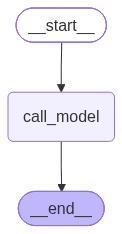

In [7]:
graph

In [8]:
config = {"configurable": {"thread_id": "chat-1"}}

result = graph.invoke(
    {"messages": [{"role": "user", "content": "Hi, my name is Chinu."}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 10
Hi, my name is Chinu.


'Hello, Chinu! Nice to meet you. How can I assist you today?'

In [9]:
result = graph.invoke(
    {"messages": [{"role": "user", "content": "I am learning LangGraph."}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 40
Hi, my name is Chinu.
Hello, Chinu! Nice to meet you. How can I assist you today?
I am learning LangGraph.


'Great to hear you’re diving into LangGraph! 🚀  \n\nBelow is a quick starter guide that covers the core concepts, typical workflow, and some handy resources to get you up and running quickly.\n\n---\n\n## 1️⃣ What is LangGraph?\n\nLangGraph is a **framework for building composable, state‑driven workflows** on top of LLMs (Large Language Models).  \nThink of it as a “graph‑engine” for LLM agents where each node (or *step*) can:\n\n| Feature | What it gives you |\n|---------|-------------------|\n| **Modular nodes** | Re‑usable pieces (prompts, tools, APIs, custom Python functions). |\n| **State management** | A shared `state` dict that flows through the graph, letting later nodes read/write data from earlier ones. |\n| **Conditional branching** | `if/else`, `switch`, or custom routing based on state values. |\n| **Loops & retries** | Built‑in support for iterative refinement or retry policies. |\n| **Observability** | Automatic logging, tracing, and visualisation of the graph execution.

In [10]:
result = graph.invoke(
    {"messages": [{"role": "user", "content": "Can you explain short term memory?"}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 13
Can you explain short term memory?


'**Short‑term memory (STM)** is the brain’s “scratch‑pad” for holding a small amount of information for a brief period—typically seconds to a few minutes—while we use it for ongoing mental tasks. Below is a concise overview of what STM is, how it works, and why it matters.\n\n---\n\n## 1. What Is Short‑Term Memory?\n\n| Feature | Description |\n|---------|-------------|\n| **Definition** | A temporary storage system that holds a limited amount of information in an active, readily accessible state. |\n| **Typical Capacity** | About **7\u202f±\u202f2** items (Miller’s classic finding), though modern research suggests the effective capacity is often closer to **4‑5 “chunks.”** |\n| **Duration** | Roughly **15‑30\u202fseconds** without rehearsal; can be extended indefinitely if the information is actively rehearsed or encoded into long‑term memory. |\n| **Function** | Keeps information online for tasks such as mental arithmetic, following a conversation, remembering a phone number long eno

In [11]:
result = graph.invoke(
    {"messages": [{"role": "user", "content": "What is my name?"}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 8
What is my name?


'I’m sorry—I don’t have any information about your name. If you’d like to share it, feel free to let me know!'

In [12]:
for item in graph.get_state({"configurable": {"thread_id": "chat-1"}}).values['messages']:
    print(item.content)
    print('-'*120)

Hi, my name is Chinu.
------------------------------------------------------------------------------------------------------------------------
Hello, Chinu! Nice to meet you. How can I assist you today?
------------------------------------------------------------------------------------------------------------------------
I am learning LangGraph.
------------------------------------------------------------------------------------------------------------------------
Great to hear you’re diving into LangGraph! 🚀  

Below is a quick starter guide that covers the core concepts, typical workflow, and some handy resources to get you up and running quickly.

---

## 1️⃣ What is LangGraph?

LangGraph is a **framework for building composable, state‑driven workflows** on top of LLMs (Large Language Models).  
Think of it as a “graph‑engine” for LLM agents where each node (or *step*) can:

| Feature | What it gives you |
|---------|-------------------|
| **Modular nodes** | Re‑usable pieces (prom